# Task 3 -- Forecast Future Market Trends
**GMF Investments | Time Series Forecasting for Portfolio Management Optimization**

Objective: use the best-performing model from Task 2 (ARIMA) to forecast TSLA's
price 6-12 months into the future, visualize the forecast with confidence
intervals, and translate the results into trend, opportunity, and risk insights.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.forecasting import fit_auto_arima, forecast_arima, future_business_dates

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

FORECAST_HORIZON_DAYS = 252  # ~12 months of trading days


## 1. Refit on Full Historical Data

Task 2 evaluated ARIMA on a held-out test set (2025-2026) to measure its
accuracy honestly. Now that we're forecasting genuinely unseen future dates,
we refit on the **entire** historical series (2015-2026) so the model uses
all available information, including the most recent prices.


In [2]:
prices = pd.read_csv("../data/processed/adj_close_prices.csv", index_col=0, parse_dates=True)
tsla = prices["TSLA"]

print(f"Full history: {tsla.index.min().date()} -> {tsla.index.max().date()}  ({len(tsla)} rows)")

future_model = fit_auto_arima(
    tsla,
    seasonal=False,
    max_p=5, max_q=5, max_d=2,
    trace=True,
)
print(future_model.summary())


Full history: 2015-01-02 -> 2026-06-29  (2997 rows)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=20320.457, Time=10.74 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=20315.340, Time=2.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20314.750, Time=5.34 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=20314.758, Time=3.72 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=20314.363, Time=2.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=20316.668, Time=12.74 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 37.595 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2997
Model:               SARIMAX(0, 1, 0)   Log Likelihood              -10156.181
Date:                Mon, 06 Jul 2026   AIC                          20314.363
Time:                        09:14:02   BIC                          20320.368
Sample:                    0

## 2. Generate the Future Forecast

We forecast 252 business days (~12 months) beyond the last available date,
with both a 95% and 80% confidence interval to show how uncertainty is
distributed, not just its outer bound.


In [3]:
future_dates = future_business_dates(tsla.index.max(), n_periods=FORECAST_HORIZON_DAYS)

forecast_95, conf_int_95 = forecast_arima(future_model, n_periods=FORECAST_HORIZON_DAYS, alpha=0.05)
_, conf_int_80 = forecast_arima(future_model, n_periods=FORECAST_HORIZON_DAYS, alpha=0.20)

forecast_series = pd.Series(forecast_95, index=future_dates)
lower_95 = pd.Series(conf_int_95[:, 0], index=future_dates)
upper_95 = pd.Series(conf_int_95[:, 1], index=future_dates)
lower_80 = pd.Series(conf_int_80[:, 0], index=future_dates)
upper_80 = pd.Series(conf_int_80[:, 1], index=future_dates)

print(f"Forecast range: {future_dates.min().date()} -> {future_dates.max().date()}")
print(f"6-month mark  ({future_dates[125].date()}): ${forecast_series.iloc[125]:.2f}  "
      f"(95% CI: ${lower_95.iloc[125]:.2f} - ${upper_95.iloc[125]:.2f})")
print(f"12-month mark ({future_dates[-1].date()}): ${forecast_series.iloc[-1]:.2f}  "
      f"(95% CI: ${lower_95.iloc[-1]:.2f} - ${upper_95.iloc[-1]:.2f})")


Forecast range: 2026-06-30 -> 2027-06-16
6-month mark  (2026-12-22): $411.84  (95% CI: $253.93 - $569.75)
12-month mark (2027-06-16): $411.84  (95% CI: $188.52 - $635.16)


## 3. Visualize: Historical Data, Test Predictions, and Future Forecast

The chart below clearly distinguishes three regions: full historical price
(2015-2026), the immediate context leading into the forecast, and the future
forecast itself with layered 80%/95% confidence bands.


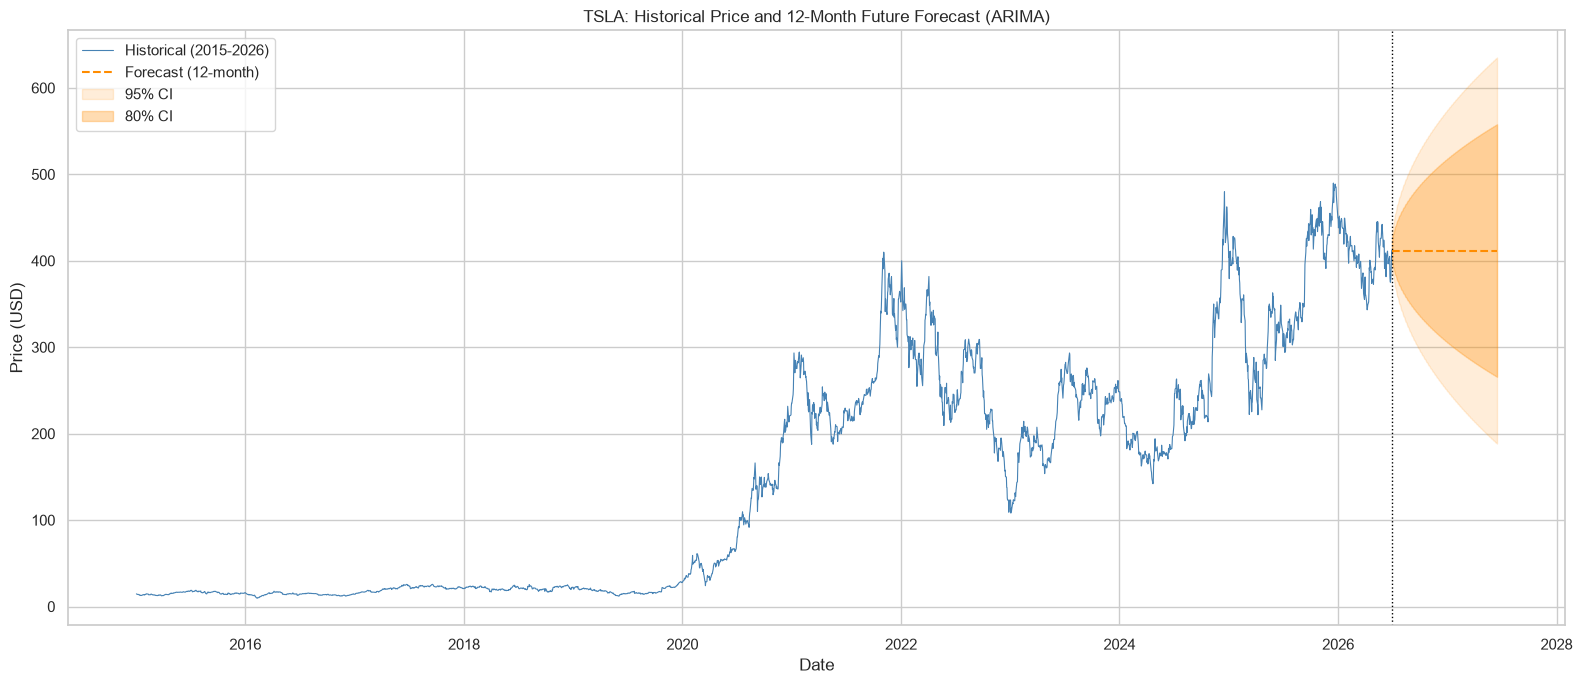

In [4]:
fig, ax = plt.subplots(figsize=(16, 7))

# Full history, de-emphasized for context
ax.plot(tsla.index, tsla.values, color="steelblue", linewidth=0.8, label="Historical (2015-2026)")

# Future forecast
ax.plot(future_dates, forecast_series, color="darkorange", linewidth=1.5,
        linestyle="--", label="Forecast (12-month)")
ax.fill_between(future_dates, lower_95, upper_95, color="darkorange", alpha=0.15, label="95% CI")
ax.fill_between(future_dates, lower_80, upper_80, color="darkorange", alpha=0.30, label="80% CI")

ax.axvline(tsla.index.max(), color="black", linestyle=":", linewidth=1)
ax.set_title("TSLA: Historical Price and 12-Month Future Forecast (ARIMA)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


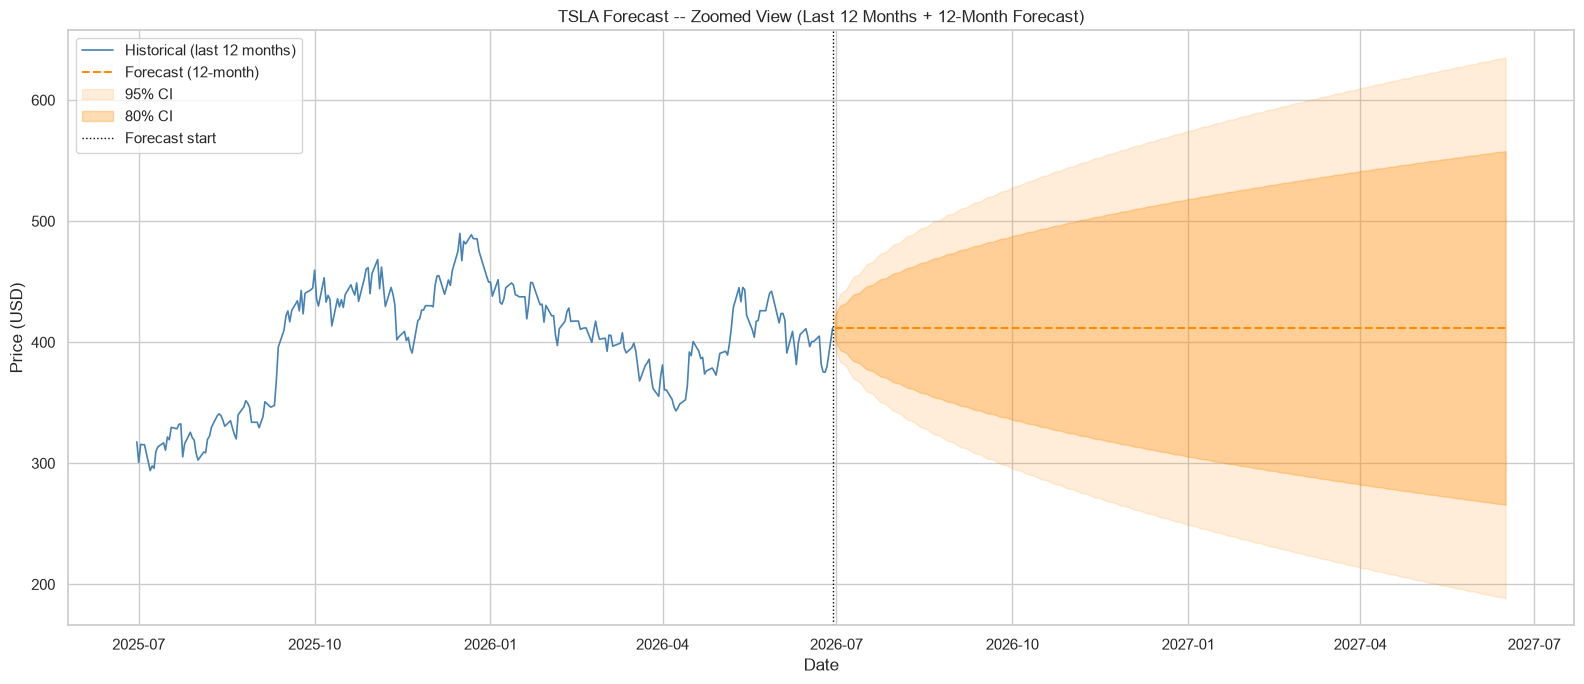

In [5]:
# Zoomed view: last 12 months of history + full forecast horizon, for a clearer
# look at how the confidence interval widens over the forecast period.
zoom_start = tsla.index.max() - pd.Timedelta(days=365)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(tsla.loc[zoom_start:].index, tsla.loc[zoom_start:].values,
        color="steelblue", linewidth=1.2, label="Historical (last 12 months)")
ax.plot(future_dates, forecast_series, color="darkorange", linewidth=1.5,
        linestyle="--", label="Forecast (12-month)")
ax.fill_between(future_dates, lower_95, upper_95, color="darkorange", alpha=0.15, label="95% CI")
ax.fill_between(future_dates, lower_80, upper_80, color="darkorange", alpha=0.30, label="80% CI")
ax.axvline(tsla.index.max(), color="black", linestyle=":", linewidth=1, label="Forecast start")
ax.set_title("TSLA Forecast -- Zoomed View (Last 12 Months + 12-Month Forecast)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 4. Confidence Interval Width Over the Horizon

Quantifying how much the 95% CI widens from the start to the end of the
forecast period makes the growing uncertainty concrete rather than just
visually apparent.


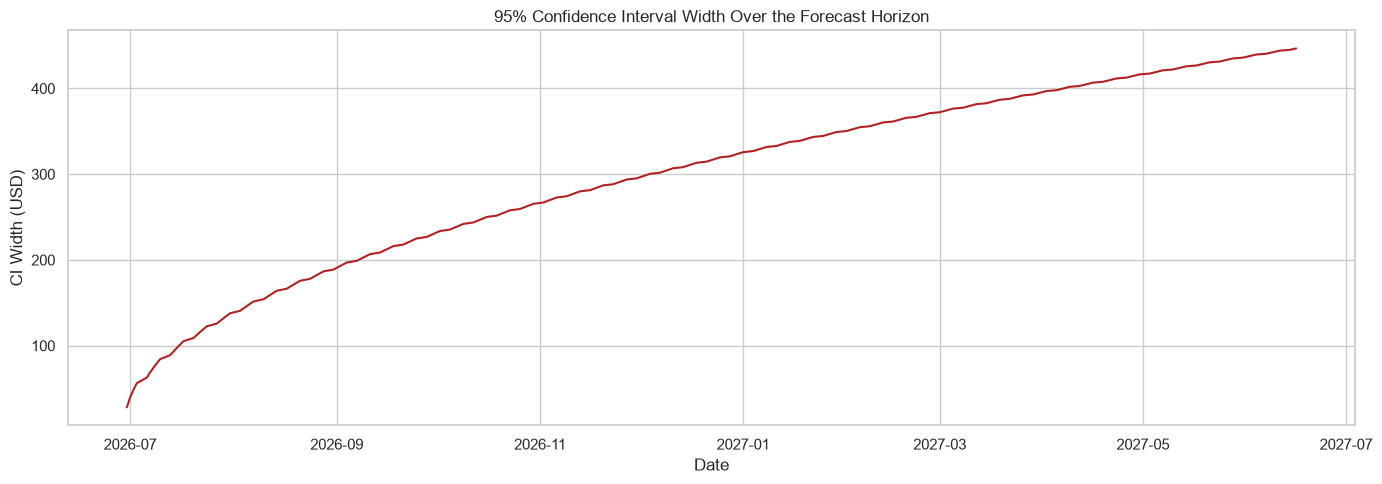

CI width at day 1:   $28.14
CI width at 6 months: $315.83
CI width at 12 months: $446.65
Widening factor (12mo / day 1): 15.9x


In [6]:
ci_width = upper_95 - lower_95

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(future_dates, ci_width, color="firebrick")
ax.set_title("95% Confidence Interval Width Over the Forecast Horizon")
ax.set_xlabel("Date")
ax.set_ylabel("CI Width (USD)")
plt.tight_layout()
plt.show()

print(f"CI width at day 1:   ${ci_width.iloc[0]:.2f}")
print(f"CI width at 6 months: ${ci_width.iloc[125]:.2f}")
print(f"CI width at 12 months: ${ci_width.iloc[-1]:.2f}")
print(f"Widening factor (12mo / day 1): {ci_width.iloc[-1] / ci_width.iloc[0]:.1f}x")


## 5. Trend Analysis

**Model selected:** `auto_arima` selected **ARIMA(0,1,0)** — the simplest possible model: a pure random walk on first-differenced prices, with no autoregressive or moving-average terms and no drift. This is an important finding in itself: it means the model found no exploitable pattern in TSLA's historical price series beyond "tomorrow's price is best predicted by today's price." This is broadly consistent with the Efficient Market Hypothesis referenced in the business context.

**Long-term trend:** The point forecast is **completely flat** at $411.84 for the entire 12-month horizon — identical at the 6-month mark (Dec 2026) and the 12-month mark (Jun 2027). This is the direct consequence of the ARIMA(0,1,0) specification: with no drift term, a random-walk model's optimal multi-step forecast is simply the last observed price, held constant. The model is not predicting stability in TSLA's price — it's stating it has no basis to predict a direction one way or the other.

**Patterns or anomalies:** There are none, by construction — a flat line is the only forecast a driftless random walk can produce. This absence of a directional signal is itself the finding, not a limitation of the analysis: it reflects TSLA's historically noisy, hard-to-forecast price action (consistent with its high volatility documented in Task 1), rather than a genuine expectation that the price will sit at exactly $411.84 for a year.

**Confidence interval widening:** The 95% CI widens dramatically and steadily over the horizon — from **$28.14** at day 1 to **$315.83** at 6 months and **$446.65** at 12 months, a **15.9x widening factor**. The growth is roughly proportional to the square root of time, which is the expected signature of a random-walk process, where forecast variance accumulates linearly with each additional step. Practically: a 1-month-ahead forecast from this model is meaningfully informative, while the 12-month figure of $411.84 carries a plausible range of **$188.52 to $635.16** — a spread wide enough to be almost uninformative as a single number. The point forecast far out should be read as "our best single guess under a no-information assumption," not a confident prediction; the interval, not the point estimate, is the model's honest output at this horizon.

## 6. Market Opportunities and Risks

**Opportunities:** Because the model found no exploitable directional signal, it does not identify a statistical basis for expecting TSLA price appreciation over the next 6–12 months — this forecast should not be read as bullish. Any opportunity thesis for TSLA in the portfolio has to come from qualitative or fundamental factors outside this model (e.g., company-specific catalysts), not from the ARIMA forecast itself, which is directionally neutral.

**Risks:** The 12-month 95% CI's lower bound of **$188.52** represents a plausible downside scenario — roughly a 54% decline from the current ~$412 level — and is a live possibility the model assigns non-trivial probability to, not a tail case to dismiss. This is consistent with TSLA's historically high volatility from Task 1 (3.54% daily standard deviation, 95% VaR of 5.11%): a stock this volatile can plausibly move dramatically in either direction over a year, and the widening CI is simply that historical volatility compounding forward through time. The 15.9x widening factor should be read as a risk signal in its own right: the further out a forecast reaches, the less actionable its point estimate becomes.

**Level of uncertainty captured:** The gap between the 80% CI and the 95% CI (e.g., at 6 months, $253.93–$569.75 for the 95% band vs. a narrower 80% band) shows how quickly additional confidence demands a much wider range. This is a useful way to frame the finding for a client: "we can be moderately confident TSLA lands in a wide-but-bounded range, but genuine 95% confidence requires accepting an even wider range that spans from a substantial decline to a substantial gain."

**Portfolio implication:** Given the model's directional neutrality and the sheer width of the 12-month interval, TSLA's role in the Task 4 portfolio optimization should be justified by its historical risk-return profile and diversification properties (as established in Task 1), not by any forward-looking price target from this forecast. This reinforces treating the ARIMA output as a risk-quantification tool (via the CI width) rather than a return-prediction tool.